In [ ]:
import pandas as pd # 导入pandas这个库，之后简称为pd。
import numpy as np # numpy是做数值计算的库。
import matplotlib.pyplot as plt # matplotlib是画图的库。
from pathlib import Path # Pathlib是Python里处理文件路径的标准库，其中Path是里面常用的一个类。

path = Path("../data/raw/Mx_1x1.txt") # 理论上也可以直接让path="../data/Mx_1x1.txt"，但是如果用了Path，我们可以检查文件是否存在，比如可以用path.exists()来返回一个布尔值。

df = pd.read_csv(path, sep=r"\s+", skiprows=2) 
# 用pendas读取一个表格文件，虽然是txt，但本质上是一个按列排列的表格，所以可以用read_csv来读。
# sep在这里表示列和列之间用什么分隔，在原txt里用的是很多空格，而\s+则是表示一个或多个空格。
# 由于表头的前两格都没有有效信息，所以我们跳过前两行。
# DataFrame可以理解成python里的Excel表，这行代码本质上是读取这个死亡率文件，然后把它变成pandas的DataFrame，然后存进变量df。


df.head() #显示前五行。

,Year,Age,Female,Male,Total
0,1933,0,0.054177,0.068175,0.061292
1,1933,1,0.008866,0.010039,0.009459
2,1933,2,0.004025,0.004671,0.004351
3,1933,3,0.002869,0.003333,0.003104
4,1933,4,0.002230,0.002537,0.002386


In [18]:
df["Age"] = df["Age"].astype(str) # df["age"]把Age整列拿出来，然后把这一整列转换成字符串格式，因为里面有一个特殊值是110+，这不是纯数字，python很难把它当整数处理，所以先全部当成文本。
df["Age_num"] = df["Age"].str.replace("+", "", regex=False).astype(int) 
# 把Age这一列的+号去掉
# regex=False是为了不把+当成一个正则表达式，在正则表达式里，+代表前面的模式重复一次或多次，为了避免歧义，我们选择False来说明只是+这个符号的替换。
# 现在没有+了，可以放心转成int。
# 转成int之后，把这个新列当成一个新列来做，叫做Age_num。
# 注意，这里的110依然不意味着精确的110岁，而是110岁以上的所有人群，这里只是为了建模上的简化，后期会处理这个问题。

df["Year"] = df["Year"].astype(int)

rate_cols = ["Female", "Male", "Total"] # 这里创建了一个list，其中每个元素都是原表格的一个列，存到变量rate_cols，在这里创建一个list的原因仅仅是为了省时间，不需要一个一个换成数字。
df[rate_cols] = df[rate_cols].apply(pd.to_numeric) 
# 注意，这里是一个双层概念，df[rate_cols]本质上是df[["Female", "Male", "Total"]]，意味着在DataFrame抓出来多个列。
# 在这个地方，我们用了.apply(pd.to_numeric)而不是.astype(float)，其实后者也可以，但前者要稳一点，
# 因为这是外部数据，如果有一些无法转换的值，比如“missing”，“NA”等等，后者则会直接报错，前者则不会，会把不能转换的值变成NaN。

df.head()

,Year,Age,Female,Male,Total,Age_num
0,1933,0,0.054177,0.068175,0.061292,0
1,1933,1,0.008866,0.010039,0.009459,1
2,1933,2,0.004025,0.004671,0.004351,2
3,1933,3,0.002869,0.003333,0.003104,3
4,1933,4,0.002230,0.002537,0.002386,4


In [ ]:
# 表格基础信息
print("Years:", df["Year"].min(), "to", df["Year"].max())
print("Ages:", df["Age_num"].min(), "to", df["Age_num"].max())
print("Number of rows:", len(df))

df.info()

Years: 1933 to 2024
Ages: 0 to 110
Number of rows: 10212
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10212 entries, 0 to 10211
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     10212 non-null  int64  
 1   Age      10212 non-null  object 
 2   Female   10212 non-null  float64
 3   Male     10212 non-null  float64
 4   Total    10212 non-null  float64
 5   Age_num  10212 non-null  int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 478.8+ KB


In [ ]:
mortality = df[["Year", "Age_num", "Total"]].copy() # copy在这里是复制一份新的表，因为我们之后可能会修改mortality，如果不copy，则有可能修改原表，所以copy是个好习惯。

mortality.head()

,Year,Age_num,Total
0,1933,0,0.061292
1,1933,1,0.009459
2,1933,2,0.004351
3,1933,3,0.003104
4,1933,4,0.002386


In [ ]:
# 最关键的一步，pivot成矩阵，由于Lee-Carter更适合用矩阵。

mx = mortality.pivot(index="Age_num", columns="Year", values="Total") # 把 Age_num 放到行索引，把 Year 放到列索引，把 Total 放到表格内部。

mx = mx.sort_index(axis=0).sort_index(axis=1) # 排序，axis = 0是排序行索引，axis = 1是排序列索引。

mx.head()

Year,1933,1934,1935,1936,1937,1938,1939,1940,1941,1942,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Age_num,,,,,,,,,,,,,,,,,,,,,
0,0.061292,0.068487,0.061509,0.062776,0.061267,0.057848,0.053392,0.053734,0.052356,0.048331,...,0.006120,0.006132,0.006057,0.005957,0.005854,0.005391,0.005543,0.005614,0.005500,0.005528
1,0.009459,0.010558,0.008912,0.008831,0.008366,0.007827,0.006302,0.005705,0.005517,0.004561,...,0.000415,0.000408,0.000402,0.000392,0.000402,0.000369,0.000403,0.000447,0.000431,0.000395
2,0.004351,0.004852,0.004146,0.004238,0.003971,0.003563,0.002909,0.002699,0.002575,0.002199,...,0.000259,0.000270,0.000255,0.000273,0.000242,0.000234,0.000255,0.000282,0.000286,0.000257
3,0.003104,0.003230,0.002980,0.002853,0.002705,0.002445,0.002094,0.001805,0.001778,0.001674,...,0.000200,0.000203,0.000198,0.000191,0.000183,0.000188,0.000192,0.000222,0.000213,0.000210
4,0.002386,0.002451,0.002404,0.002272,0.002138,0.001930,0.001681,0.001482,0.001408,0.001344,...,0.000149,0.000163,0.000152,0.000150,0.000145,0.000139,0.000161,0.000167,0.000162,0.000169


In [ ]:
# 矩阵信息和检查缺失值

print("Matrix shape:", mx.shape)
print("Missing values:", mx.isna().sum().sum()) 
# 这个很经典。mx.isna()是检查每一个格子是不是missing value，如果有就是True，没有就是False。
# 在pandas里，True被当成1，False被当成0。
# 第一个sum，也就是mx.isna().sum()，等价于mx.isna().sum(axis = 0)。这是按列统计缺失值数量，经过第一个sum之后 所有的行内部都被加了起来。
# 第二个sum，则把所有行的sum加了起来，也就是一个列的sum。
# 这两个sum得出来的结果就是所有的missing value。

mx.iloc[:10, :5]

Matrix shape: (111, 92)
Missing values: 0


Year,1933,1934,1935,1936,1937
Age_num,,,,,
0,0.061292,0.068487,0.061509,0.062776,0.061267
1,0.009459,0.010558,0.008912,0.008831,0.008366
2,0.004351,0.004852,0.004146,0.004238,0.003971
3,0.003104,0.003230,0.002980,0.002853,0.002705
4,0.002386,0.002451,0.002404,0.002272,0.002138
5,0.001975,0.002029,0.002009,0.001886,0.001778
6,0.001774,0.001823,0.001801,0.001702,0.001578
7,0.001611,0.001647,0.001617,0.001550,0.001426
8,0.001469,0.001507,0.001473,0.001418,0.001303


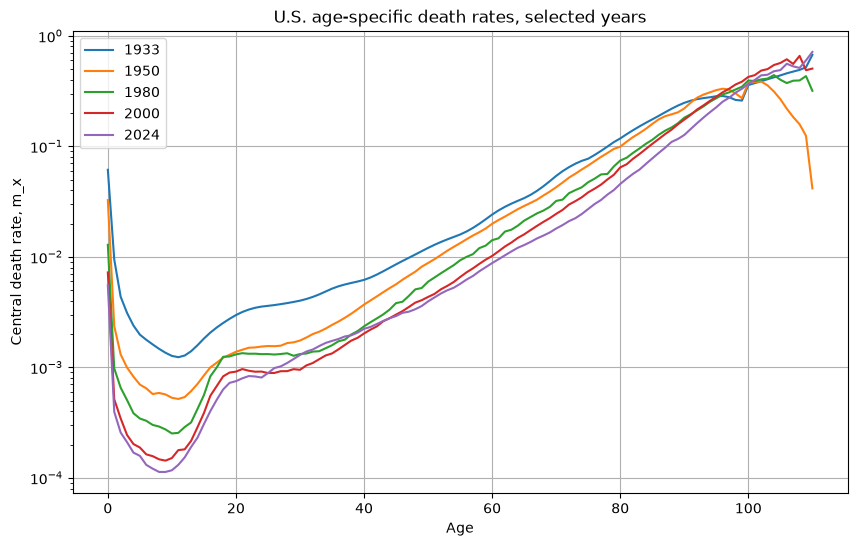

In [ ]:
# 画图

selected_years = [1933, 1950, 1980, 2000, 2024]

plt.figure(figsize=(10, 6)) # 图的宽度是10.高度是6.

for year in selected_years:
    plt.plot(mx.index, mx[year], label=str(year)) # mx.index在这里是行索引，也就是年龄。mx[year]在这里则是在某一年的死亡率。所以x轴是年龄，y轴是某一年的死亡率。并给每条线一个名字。

plt.yscale("log") # 把y轴改成log scale。
plt.xlabel("Age") 
plt.ylabel("Central death rate, m_x") 
plt.title("U.S. age-specific death rates, selected years") 
plt.legend() # 显示label框，这样我们才知道哪一条是哪一条。
plt.grid(True)
plt.show()

In [ ]:
log_mx = np.log(mx) # 对mx取自然对数。

log_mx.head()

Year,1933,1934,1935,1936,1937,1938,1939,1940,1941,1942,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Age_num,,,,,,,,,,,,,,,,,,,,,
0,-2.792106,-2.681111,-2.788572,-2.768182,-2.792514,-2.849936,-2.930094,-2.923709,-2.949689,-3.029682,...,-5.096193,-5.094234,-5.106541,-5.123188,-5.140630,-5.223024,-5.195219,-5.182492,-5.203007,-5.197929
1,-4.660789,-4.550871,-4.720357,-4.729487,-4.783579,-4.850176,-5.066888,-5.166412,-5.199921,-5.390213,...,-7.787232,-7.804243,-7.819058,-7.844249,-7.819058,-7.904714,-7.816574,-7.712952,-7.749402,-7.836625
2,-5.437350,-5.328364,-5.485611,-5.463664,-5.528737,-5.637152,-5.839946,-5.914874,-5.961906,-6.119753,...,-8.258682,-8.217089,-8.274247,-8.206039,-8.326573,-8.360189,-8.274247,-8.173603,-8.159519,-8.266434
3,-5.775064,-5.735273,-5.815832,-5.859384,-5.912653,-6.013710,-6.168679,-6.317195,-6.332266,-6.392539,...,-8.517193,-8.502305,-8.527244,-8.563237,-8.606024,-8.579069,-8.558015,-8.412833,-8.454218,-8.468403
4,-6.038137,-6.011259,-6.030621,-6.087095,-6.147884,-6.250235,-6.388366,-6.514363,-6.565585,-6.612105,...,-8.811564,-8.721760,-8.791630,-8.804875,-8.838777,-8.881037,-8.734106,-8.697517,-8.727914,-8.685612


In [13]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

mx.to_csv(processed_dir / "us_total_mortality_matrix.csv")
log_mx.to_csv(processed_dir / "us_total_log_mortality_matrix.csv")

print("Saved processed mortality matrices.")

Saved processed mortality matrices.
